
## Academic Integrity and Learning Statement

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## E. EDA: Time-series data

Another data type that requires specific methods and skills for analysis is time-series data. Although the Open Food database is not a time-series database, it contains several columns with dates and times, allowing for a simple investigation. In this task, you will work with the created_at column that stores the date and time at which products were added to the Open Food database. You will analyze the total number of products added to the database.

- Your task is to investigate the total number of items created each month at each hour. You should use the created_at column to draw a heatmap with the hours (0 to 23) on the x-axis and the months (1 to 12) on the y-axis. Please ensure that the heatmap displays the number of items created at each month-hour pair in an informative way. As always include any observations and their discussion.

- Your task is to investigate the evolution of the total number of items over time. You should draw a bar plot with the date (e.g., in yyyy-mm format) on the x-axis and the total number of items created during each month on the y-axis. Each bar in the plot should stack the number of items created by each country each month. Please make sure all bars are visible by choosing the appropriate scale for the y-axis. Your output should look like the following plot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("data_clean.csv")
df["created_at"] = pd.to_datetime(df["created_at"])



/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3441: DtypeWarning: Columns (1,43,45) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [7]:
# Group the data by month and by hour and calculate the total number of items per month and per hour
# This creates a data frame with a multi-index (month, hour) with the numer of products created as a value
counts = df.groupby([df["created_at"].dt.month, df["created_at"].dt.hour])["product_name_en"].size()

# unstack is necessary for the heatmap, we want month vs hour
counts = counts.unstack()

counts.columns.name = "Hours"
counts.index.name = "Months"

# fill 0 for missing values
counts = counts.fillna(0)
counts

Hours,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Months,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,27.0,85.0,128.0,...,44.0,33.0,5.0,20.0,37.0,6.0,13.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,159.0,97.0,...,30.0,18.0,4.0,5.0,0.0,39.0,5.0,24.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,25.0,283.0,148.0,...,388.0,386.0,78.0,14.0,5.0,12.0,46.0,3.0,0.0,1.0
4,0.0,8.0,0.0,0.0,6.0,24.0,302.0,98.0,160.0,139.0,...,72.0,12.0,10.0,14.0,2.0,90.0,8.0,17.0,0.0,0.0
5,0.0,0.0,1.0,0.0,1.0,0.0,4.0,91.0,70.0,31.0,...,29.0,14.0,8.0,148.0,54.0,7.0,0.0,0.0,0.0,0.0
6,4.0,0.0,18.0,0.0,0.0,0.0,27.0,46.0,40.0,50.0,...,119.0,31.0,122.0,147.0,43.0,3.0,5.0,4.0,196.0,41.0
7,29.0,4.0,0.0,0.0,0.0,0.0,414.0,49.0,51.0,61.0,...,55.0,46.0,278.0,141.0,83.0,62.0,552.0,42.0,30.0,202.0
8,15.0,12.0,7.0,2.0,0.0,8.0,31.0,264.0,70.0,333.0,...,95.0,91.0,189.0,106.0,80.0,184.0,70.0,42.0,28.0,3.0
9,0.0,0.0,0.0,1.0,5.0,9.0,67.0,72.0,59.0,340.0,...,226.0,83.0,205.0,640.0,1221.0,112.0,6.0,50.0,1.0,0.0


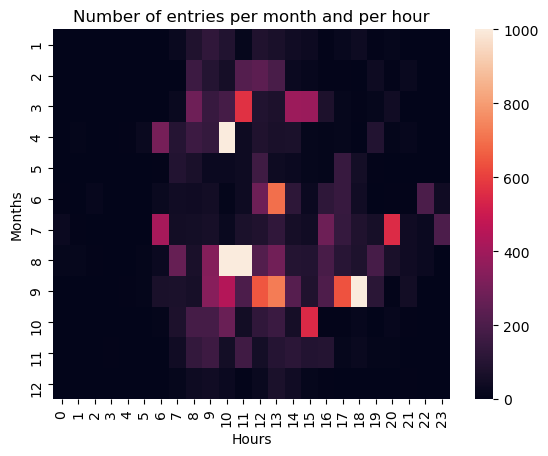

In [8]:
import seaborn as sns
sns.heatmap(counts, vmin=0, vmax=1000)
plt.title("Number of entries per month and per hour")
plt.show()


#### Comments

We observe that more entries were created around noon (or at least during working hours). Almost no entries were created during the night (black). 

In [9]:
# Investigate the evolution of the total number of items over time. 
# Draw a bar plot with the date on the x axis
# and the total number of items created during each month on the y axis

df_country_months = df.groupby("country").resample("M", on="created_at").size()

In [10]:
# Make your data frame in a format that's easier to plot
df_country_months = df_country_months.unstack().transpose()

# Keep only the date in the index, not the time and timezone
df_country_months.index = df_country_months.index.date

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


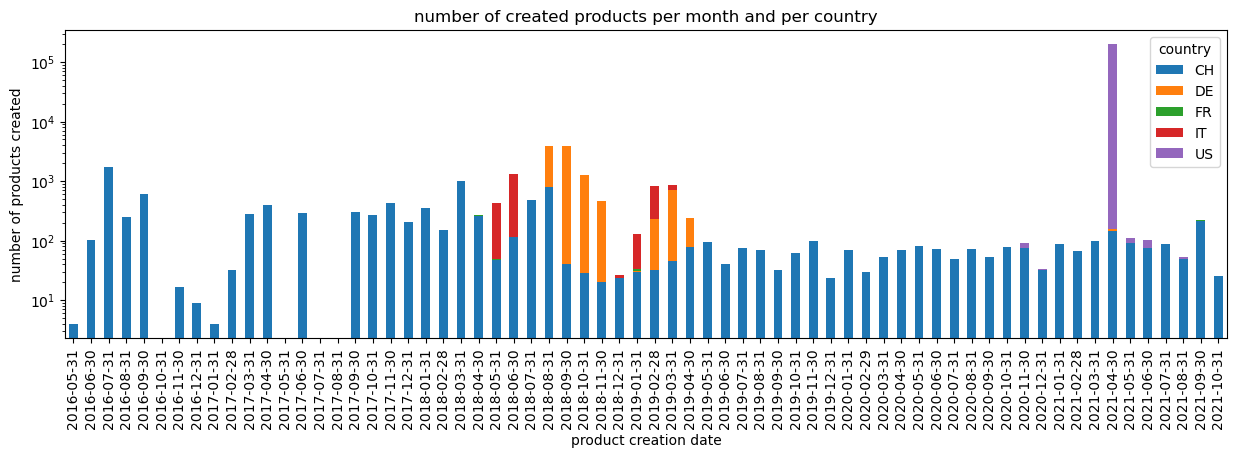

In [11]:
df_country_months.plot(kind="bar", stacked=True, figsize=(15,4))
plt.yscale("log")
plt.xlabel("product creation date")
plt.ylabel("number of products created")
plt.title("number of created products per month and per country")
plt.show()

#### Comments,

Interestingly we see that all of the entries for the US were added at more or less the same time, while the database has been updated much more regularly for swiss products. For Italian and german products, most were created in 2018-2019. 